In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Cargar los datasets (asegúrate de que los archivos estén en la misma carpeta)
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

print(f"Dataset de Entrenamiento: {train.shape}")
print(f"Dataset de Test: {test.shape}")
train.head()

Dataset de Entrenamiento: (26570, 26)
Dataset de Test: (20775, 25)


,id,product_code,loading,attribute_0,attribute_1,attribute_2,attribute_3,measurement_0,measurement_1,measurement_2,...,measurement_9,measurement_10,measurement_11,measurement_12,measurement_13,measurement_14,measurement_15,measurement_16,measurement_17,failure
0,0,A,80.10,material_7,material_8,9,5,7,8,4,...,10.672,15.859,17.594,15.193,15.029,NaN,13.034,14.684,764.100,0
1,1,A,84.89,material_7,material_8,9,5,14,3,3,...,12.448,17.947,17.915,11.755,14.732,15.425,14.395,15.631,682.057,0
2,2,A,82.43,material_7,material_8,9,5,12,1,5,...,12.715,15.607,NaN,13.798,16.711,18.631,14.094,17.946,663.376,0
3,3,A,101.07,material_7,material_8,9,5,13,2,6,...,12.471,16.346,18.377,10.020,15.250,15.562,16.154,17.172,826.282,0
4,4,A,188.06,material_7,material_8,9,5,9,2,8,...,10.337,17.082,19.932,12.428,16.182,12.760,13.153,16.412,579.885,0


In [2]:
def preprocess_data(df):
    df = df.copy()
    # Identificar columnas categóricas (objetos)
    cat_cols = df.select_dtypes(include=['object']).columns
    for col in cat_cols:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str))
    
    # Imputar valores faltantes con la mediana
    imputer = SimpleImputer(strategy='median')
    df_imputed = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)
    return df_imputed

# Aplicar preprocesamiento
train_clean = preprocess_data(train)
test_clean = preprocess_data(test)

--- RESULTADOS ADABOOST ---
AUC medio: 0.8081
Inestabilidad (Desviación): 0.3839
------------------------------


C:\Users\pedro\AppData\Local\Temp\ipykernel_50540\4197083290.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=importances.head(10), palette='magma')


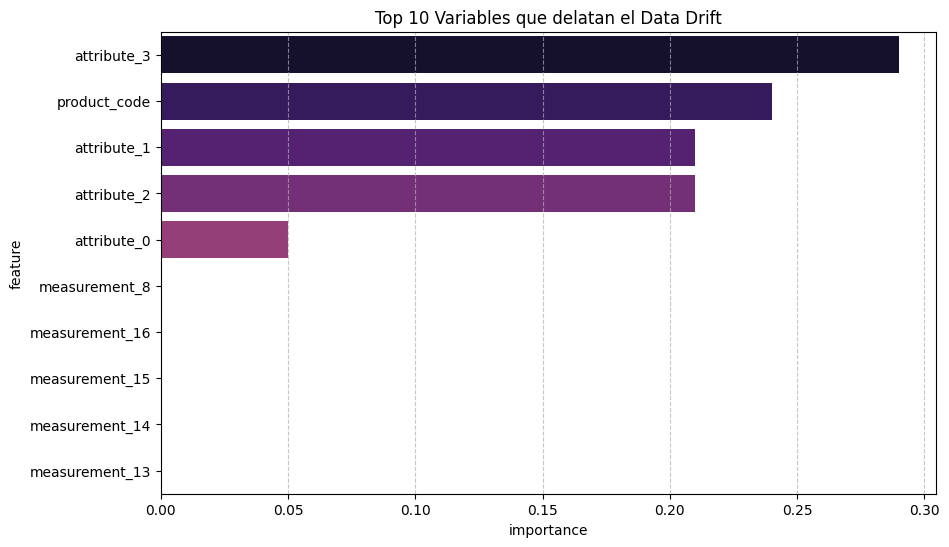

TOP VARIABLES QUE CAUSAN DRIFT:
        feature  importance
5   attribute_3        0.29
0  product_code        0.24
3   attribute_1        0.21
4   attribute_2        0.21
2   attribute_0        0.05


In [ ]:
from sklearn.ensemble import AdaBoostClassifier
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Configurar el modelo AdaBoost
# Es más sensible que el Random Forest a los patrones difíciles
model_ada = AdaBoostClassifier(n_estimators=100, random_state=42)

# 2. Entrenar con el dataset completo para extraer importancias
model_ada.fit(X_adv, y_adv)

# 3. Calcular el AUC con validación cruzada (para ver la estabilidad)
cv_scores_ada = cross_val_score(model_ada, X_adv, y_adv, cv=5, scoring='roc_auc')

print(f"--- RESULTADOS ADABOOST ---")
print(f"AUC medio: {cv_scores_ada.mean():.4f}")
print(f"Inestabilidad (Desviación): {cv_scores_ada.std():.4f}")
print("-" * 30)

# 4. EXTRAER VARIABLES CLAVE (¿Quién causa el Drift?)
importances = pd.DataFrame({
    'feature': X_adv.columns,
    'importance': model_ada.feature_importances_
}).sort_values(by='importance', ascending=False)

# 5. Visualización de las variables "chivatas"
plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=importances.head(10), hue='feature', palette='magma', legend=False)
plt.title('Top 10 Variables que delatan el Data Drift')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

print("TOP VARIABLES QUE CAUSAN DRIFT:")
print(importances.head(5))

In [4]:
# Preparar datos para la predicción real
X = train_clean.drop(['id', 'failure'], axis=1)
y = train_clean['failure']
X_test_final = test_clean.drop(['id'], axis=1)

# Usar Escalado (importante para modelos lineales como Logistic Regression)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_test_scaled = scaler.transform(X_test_final)

# Entrenar modelo (Regresión Logística es muy sólida para este tipo de retos)
model_failure = LogisticRegression(max_iter=1000)
model_failure.fit(X_scaled, y)

# Validación cruzada para ver rendimiento esperado
cv_failure = cross_val_score(model_failure, X_scaled, y, cv=5, scoring='roc_auc')
print(f"AUC estimado para predicción de fallos: {cv_failure.mean():.4f}")

AUC estimado para predicción de fallos: 0.5928


In [5]:
# Predecir probabilidades (likelihood)
predictions = model_failure.predict_proba(X_test_scaled)[:, 1]

# Crear dataframe de resultados
submission = pd.DataFrame({
    'id': test['id'],
    'failure': predictions
})

# Guardar a CSV
submission.to_csv('submission.csv', index=False)
print("Archivo 'submission.csv' generado con éxito.")
submission.head()

Archivo 'submission.csv' generado con éxito.


,id,failure
0,26570,0.203466
1,26571,0.152684
2,26572,0.179240
3,26573,0.181928
4,26574,0.333665
